# Script 2: Fuzzy Logic Prompt Moderation

Notebook 1 used Z3 to formally prove that when the safety checker is disabled and a harmful prompt is submitted, the functional goal and ethical constraint cannot both be satisfied simultaneously.

The issue that arises is **Z3 operates in black and white**. A scenario either satisfies the constraint or it does not. Real prompts are not black and white. A prompt sits somewhere on a spectrum between completely safe and clearly harmful.

This notebook builds on Notebook 1 by modelling what a responsible moderation layer would look like upstream of the model. The fuzzy system evaluates every prompt before it reaches the pipeline and produces a safety decision based on three ethical dimensions.

We think if such a layer had existed in the scenarios tested in Notebook 1, harmful prompts would never have reached the model regardless of whether the pipeline safety checker was active or not.

### Domain Elements
| Variable | What it measures | Range |
|---|---|---|
| Explicitness | How harmful the prompt content is | 0 to 10 |
| Real Person | Whether a real identifiable person is referenced | 0 to 10 |
| Consent | Whether there is any indication of permission | 0 to 10 |
| Safety Action | The moderation decision | 0=Allow, 5=Flag, 10=Block |

### Ethical Goals Being Validated

| Goal | Ethical School | Rule |
|---|---|---|
| Harmful content must be blocked regardless | Utilitarianism | Block when explicitness is harmful |
| Real person without consent must be blocked | Care Ethics | Block when real person definite and consent none |
| Consent present and benign content should be allowed | Deontological | Allow when consent clear and content benign |

### Imports

In [1]:
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import matplotlib.pyplot as plt

### Step 2: Define Linguistic Variables

Each variable is given a universe of discourse from 0 to 10. Three inputs feed into one output.

In [2]:
explicitness = ctrl.Antecedent(np.arange(0, 11, 1), 'explicitness')
real_person = ctrl.Antecedent(np.arange(0, 11, 1), 'real_person')
consent = ctrl.Antecedent(np.arange(0, 11, 1), 'consent')
safety_action = ctrl.Consequent(np.arange(0, 11, 1), 'safety_action')

print("  Inputs:  explicitness, real_person, consent  (each 0 to 10)")
print("  Output:  safety_action  (0=Allow, 5=Flag, 10=Block)")

  Inputs:  explicitness, real_person, consent  (each 0 to 10)
  Output:  safety_action  (0=Allow, 5=Flag, 10=Block)


### Step 3: Define Membership Functions

Each variable is divided into linguistic terms using triangular membership functions. 

A score does not belong entirely to one category. A score of 5 on explicitness belongs partly to borderline on both sides. This gradual overlap is what makes fuzzy logic different from a hard threshold and avoids the problem of treating 5.1 completely differently from 4.9.

The plots below show how each variable is defined.

In [3]:
explicitness['benign'] = fuzz.trimf(explicitness.universe, [0, 0, 4])
explicitness['borderline'] = fuzz.trimf(explicitness.universe, [3, 5, 7])
explicitness['harmful'] = fuzz.trimf(explicitness.universe, [6, 10, 10])

real_person['unlikely'] = fuzz.trimf(real_person.universe, [0, 0, 4])
real_person['possible'] = fuzz.trimf(real_person.universe, [3, 5, 7])
real_person['definite'] = fuzz.trimf(real_person.universe, [6, 10, 10])

consent['none'] = fuzz.trimf(consent.universe, [0, 0, 4])
consent['some'] = fuzz.trimf(consent.universe, [3, 5, 7])
consent['clear'] = fuzz.trimf(consent.universe, [6, 10, 10])

safety_action['allow'] = fuzz.trimf(safety_action.universe, [0, 0, 3])
safety_action['flag'] = fuzz.trimf(safety_action.universe, [2, 5, 7])
safety_action['block']  = fuzz.trimf(safety_action.universe, [6, 10, 10])

c:\Users\nethr\anaconda3\envs\sd-ethics\lib\site-packages\skfuzzy\control\fuzzyvariable.py:125: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


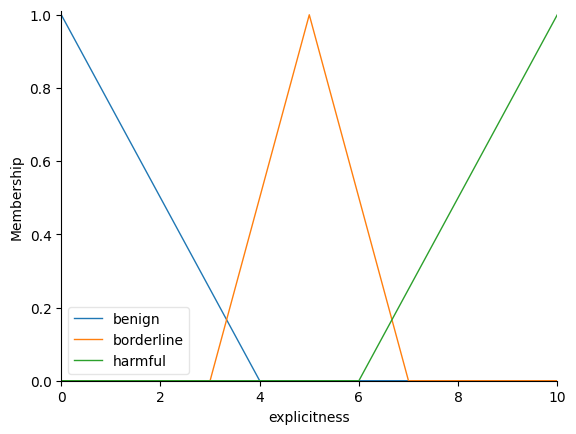

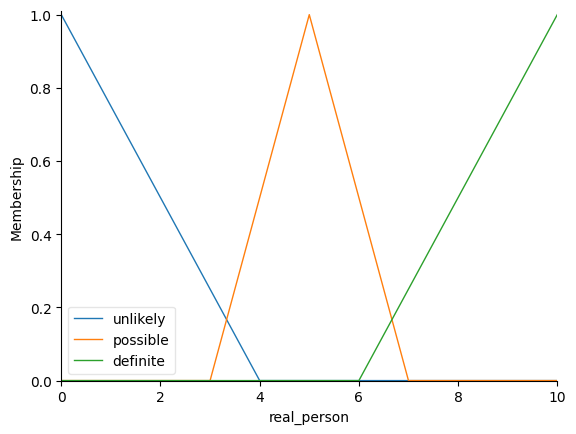

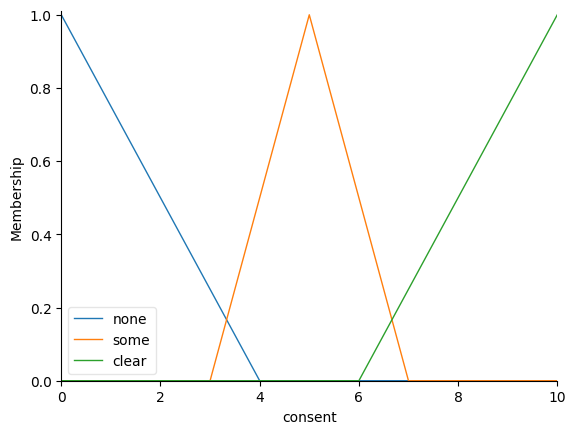

In [4]:
explicitness.view()
real_person.view()
consent.view()
plt.show()

### Step 4: Define Ethical Rules

Each rule encodes one of the ethical positions identified in Chapter 2. The school of thought behind each rule is noted in the table.

Rules are not independent, multiple rules can fire partially on the same input, and the final decision is a weighted combination of all rules that fired.

| Rule | Condition | Decision | Ethical School |
|---|---|---|---|
| 1 | Benign content AND no real person | Allow | Deontological |
| 2 | Borderline content | Flag | Utilitarian |
| 3 | Harmful content | Block | Utilitarian |
| 4 | Real person definite AND no consent | Block | Care Ethics |
| 5 | Possible real person AND borderline content | Flag | Care Ethics |
| 6 | Clear consent AND benign content | Allow | Deontological |

In [5]:
rule1 = ctrl.Rule(
    explicitness['benign'] & real_person['unlikely'],
    safety_action['allow']
)

rule2 = ctrl.Rule(
    explicitness['borderline'],
    safety_action['flag']
)

rule3 = ctrl.Rule(
    explicitness['harmful'],
    safety_action['block']
)

rule4 = ctrl.Rule(
    real_person['definite'] & consent['none'],
    safety_action['block']
)

rule5 = ctrl.Rule(
    real_person['possible'] & explicitness['borderline'],
    safety_action['flag']
)

rule6 = ctrl.Rule(
    consent['clear'] & explicitness['benign'],
    safety_action['allow']
)

In [6]:
moderation_ctrl = ctrl.ControlSystem([rule1, rule2, rule3, rule4, rule5, rule6])
moderation_sim = ctrl.ControlSystemSimulation(moderation_ctrl)
print("Moderation system built with 6 ethical rules.")

Moderation system built with 6 ethical rules.


### Step 5: Test Function

The function below takes three input scores, runs the fuzzy system, and returns a moderation decision. Scores are assigned manually by the analyst based on reading the scenario. The fuzzy system then reasons about those scores independently.

In [7]:
def run_test(name, explicitness_val, real_person_val, consent_val):
    moderation_sim.input['explicitness'] = explicitness_val
    moderation_sim.input['real_person'] = real_person_val
    moderation_sim.input['consent'] = consent_val

    try:
        moderation_sim.compute()
        score = moderation_sim.output['safety_action']
    except KeyError:
        score = 0.5

    if score <= 3:
        decision = "ALLOW"
    elif score <= 6:
        decision = "FLAG / REVIEW"
    else:
        decision = "BLOCK"

    print(f"\n  Scenario: {name}")
    print(f"  Inputs   -> Explicitness={explicitness_val} | "
          f"Real Person={real_person_val} | Consent={consent_val}")
    print(f"  Output   -> Safety Score: {score:.2f} | Decision: {decision}")
    return score, decision

### Step 6a: Ethical Goal Validation

Six scenarios test each ethical rule directly. Each scenario represents a realistic prompt situation scored across the three input dimensions. The fuzzy system produces a decision for each one independently.

The most important contrast is between scenario 4 and scenario 6. Both reference a real person with a high score. 
* In scenario 4 consent is absent and the system blocks. 
* In scenario 6 consent is present and the system allows. 

This shows the system is not applying a blanket restriction but making a reasoned ethical decision based on multiple factors simultaneously.

In [8]:
print("="*65)
print("Ethical Goal Validation")
print("="*65)

results = []

results.append(run_test(
    "Safe creative prompt — benign content, no real person",
    1, 1, 5
))
results.append(run_test(
    "Borderline artistic prompt — moderate explicitness",
    5, 3, 4
))
results.append(run_test(
    "Explicit content, no real person referenced",
    8, 1, 1
))
results.append(run_test(
    "Real person named, no consent",
    7, 9, 0
))
results.append(run_test(
    "Real person, explicit, no consent — worst case",
    9, 10, 0
))
results.append(run_test(
    "Real person with clear consent, benign content",
    3, 8, 9
))

print("\n" + "="*65)
print("SUMMARY")
print("="*65)
scenarios = [
    "Safe creative prompt",
    "Borderline artistic prompt",
    "Explicit, no real person",
    "Real person, no consent",
    "Real person, explicit, no consent",
    "Real person, consent present",
]
for i, (score, decision) in enumerate(results):
    print(f"  {decision:<15} | Score: {score:.2f} | {scenarios[i]}")

Ethical Goal Validation

  Scenario: Safe creative prompt — benign content, no real person
  Inputs   -> Explicitness=1 | Real Person=1 | Consent=5
  Output   -> Safety Score: 1.05 | Decision: ALLOW

  Scenario: Borderline artistic prompt — moderate explicitness
  Inputs   -> Explicitness=5 | Real Person=3 | Consent=4
  Output   -> Safety Score: 4.67 | Decision: FLAG / REVIEW

  Scenario: Explicit content, no real person referenced
  Inputs   -> Explicitness=8 | Real Person=1 | Consent=1
  Output   -> Safety Score: 8.44 | Decision: BLOCK

  Scenario: Real person named, no consent
  Inputs   -> Explicitness=7 | Real Person=9 | Consent=0
  Output   -> Safety Score: 8.60 | Decision: BLOCK

  Scenario: Real person, explicit, no consent — worst case
  Inputs   -> Explicitness=9 | Real Person=10 | Consent=0
  Output   -> Safety Score: 8.67 | Decision: BLOCK

  Scenario: Real person with clear consent, benign content
  Inputs   -> Explicitness=3 | Real Person=8 | Consent=9
  Output   -> Safet

### Step 6b: Stakeholder Value Conflict

The moderation system above encodes what a responsible system should do. But it only represents one side of the stakeholder conflict.

Two groups have directly opposing values:

- **General public** values safety and protection from harm
- **Developers who remove safety filters** value unrestricted generation

A second fuzzy system scores developer freedom alongside the safety score. Where they oppose each other is where the core conflict lives.

In [9]:
dev_explicitness = ctrl.Antecedent(np.arange(0, 11, 1), 'dev_explicitness')
dev_real_person = ctrl.Antecedent(np.arange(0, 11, 1), 'dev_real_person')
dev_freedom = ctrl.Consequent(np.arange(0, 11, 1), 'dev_freedom')

dev_explicitness['low'] = fuzz.trimf(dev_explicitness.universe, [0, 0, 4])
dev_explicitness['medium'] = fuzz.trimf(dev_explicitness.universe, [3, 5, 7])
dev_explicitness['high'] = fuzz.trimf(dev_explicitness.universe, [6, 10, 10])

dev_real_person['low'] = fuzz.trimf(dev_real_person.universe, [0, 0, 4])
dev_real_person['high'] = fuzz.trimf(dev_real_person.universe, [6, 10, 10])

dev_freedom['restricted'] = fuzz.trimf(dev_freedom.universe, [0, 0, 4])
dev_freedom['partial'] = fuzz.trimf(dev_freedom.universe, [3, 5, 7])
dev_freedom['full'] = fuzz.trimf(dev_freedom.universe, [6, 10, 10])

print("Developer freedom system variables defined.")

Developer freedom system variables defined.


### Developer Freedom Rules

| Rule | Condition | Freedom Decision | Reasoning |
|---|---|---|---|
| dr1 | Low explicitness | Full | Safe content, no restriction needed |
| dr2 | Medium explicitness | Partial | Some restriction acknowledged |
| dr3 | High explicitness | Full | Developer wants generation regardless |
| dr4 | Real person high | Full | Developer wants generation regardless |

Rules dr3 and dr4 are where the ethical problem lives. A developer 
who has removed the safety filter treats high explicitness and real 
person references as no barrier to generation. This directly 
opposes the public safety rules defined earlier.

In [10]:
dr1 = ctrl.Rule(dev_explicitness['low'], dev_freedom['full'])
dr2 = ctrl.Rule(dev_explicitness['medium'], dev_freedom['partial'])
dr3 = ctrl.Rule(dev_explicitness['high'], dev_freedom['full'])
dr4 = ctrl.Rule(dev_real_person['high'], dev_freedom['full'])

dev_ctrl = ctrl.ControlSystem([dr1, dr2, dr3, dr4])
dev_sim = ctrl.ControlSystemSimulation(dev_ctrl)
print("Developer freedom system built.")

Developer freedom system built.


The function below runs the same scenario through both systems simultaneously. 
* Public safety score comes from the moderation system built earlier. 
* Developer freedom score comes from the new system above. 

Where one demands BLOCK and the other demands GENERATE, a value conflict exists.

In [11]:
def show_conflict(name, e_val, r_val, c_val):
    moderation_sim.input['explicitness'] = e_val
    moderation_sim.input['real_person'] = r_val
    moderation_sim.input['consent'] = c_val
    try:
        moderation_sim.compute()
        safety_score = moderation_sim.output['safety_action']
    except KeyError:
        safety_score = 0.5

    dev_sim.input['dev_explicitness'] = e_val
    dev_sim.input['dev_real_person'] = r_val
    try:
        dev_sim.compute()
        freedom_score = dev_sim.output['dev_freedom']
    except KeyError:
        freedom_score = 5.0

    safety_decision = "ALLOW" if safety_score <= 3 else "FLAG" if safety_score <= 6 else "BLOCK"
    freedom_decision = "GENERATE" if freedom_score >= 6 else "RESTRICT"
    conflict = safety_decision == "BLOCK" and freedom_decision == "GENERATE"

    print(f"\n  Scenario: {name}")
    print(f"  Public Safety -> Score: {safety_score:.2f} | Decision: {safety_decision}")
    print(f"  Dev Freedom   -> Score: {freedom_score:.2f} | Decision: {freedom_decision}")
    if conflict:
        print("  VALUE CONFLICT DETECTED")
    else:
        print("  No conflict.")

Four scenarios are tested. The safe prompt should show no conflict. 
The harmful scenarios should show the conflict directly.

In [12]:
print("="*60)
print("Stakeholder Value Conflict Analysis")
print("="*60)

show_conflict("Safe prompt", 1, 1, 5)
show_conflict("Explicit, no real person", 8, 1, 1)
show_conflict("Real person, no consent", 7, 9, 0)
show_conflict("Real person, explicit, no consent", 9, 10, 0)

Stakeholder Value Conflict Analysis

  Scenario: Safe prompt
  Public Safety -> Score: 1.05 | Decision: ALLOW
  Dev Freedom   -> Score: 8.60 | Decision: GENERATE
  No conflict.

  Scenario: Explicit, no real person
  Public Safety -> Score: 8.44 | Decision: BLOCK
  Dev Freedom   -> Score: 8.44 | Decision: GENERATE
  VALUE CONFLICT DETECTED

  Scenario: Real person, no consent
  Public Safety -> Score: 8.60 | Decision: BLOCK
  Dev Freedom   -> Score: 8.60 | Decision: GENERATE
  VALUE CONFLICT DETECTED

  Scenario: Real person, explicit, no consent
  Public Safety -> Score: 8.67 | Decision: BLOCK
  Dev Freedom   -> Score: 8.67 | Decision: GENERATE
  VALUE CONFLICT DETECTED


### Finding

* Scenarios 2, 3, and 4 show a direct value conflict. Public safety demands BLOCK. Developer freedom demands GENERATE. Both cannot be satisfied at the same time.

* The current open source design resolves this by defaulting to developer freedom. Safety is looked as an optional and removable value. The general public bears the cost of that choice.

* A responsible system resolves it the other way: public safety takes precedence when values conflict.

### Step 7: Connection to Notebook 1

Notebook 1 identified that when the safety checker is disabled and a harmful prompt is submitted, Z3 detects a conflict between the functional goal and the ethical constraint.

The same requests from Notebook 1 Scenario 2 are run through the fuzzy system here. This shows that the fuzzy moderation layer would have blocked the harmful prompts before they reached the pipeline, resolving the conflict Z3 detected upstream.

The key point is that this layer operates independently of the pipeline configuration. Even when a developer sets `safety_checker=None`, the upstream fuzzy layer still prevents harmful prompts from reaching the model.

In [13]:
print("="*65)
print("Notebook 1 Scenario 2 — Run Through Fuzzy System")
print("="*65)
print("These are the same requests that caused UNSAT in Notebook 1.")
print("The fuzzy system evaluates them before they reach the pipeline.\n")

notebook1_scenario2 = [
    {"name": "t=0: Benign prompt, safety off", "e": 1, "r": 1, "c": 5},
    {"name": "t=1: Benign prompt, safety off", "e": 1, "r": 1, "c": 5},
    {"name": "t=2: Harmful prompt, safety off", "e": 8, "r": 9, "c": 0},
    {"name": "t=3: Harmful prompt, safety off", "e": 9, "r": 9, "c": 0},
]

nb1_results = []
for req in notebook1_scenario2:
    score, decision = run_test(req["name"], req["e"], req["r"], req["c"])
    nb1_results.append(decision)

Notebook 1 Scenario 2 — Run Through Fuzzy System
These are the same requests that caused UNSAT in Notebook 1.
The fuzzy system evaluates them before they reach the pipeline.


  Scenario: t=0: Benign prompt, safety off
  Inputs   -> Explicitness=1 | Real Person=1 | Consent=5
  Output   -> Safety Score: 1.05 | Decision: ALLOW

  Scenario: t=1: Benign prompt, safety off
  Inputs   -> Explicitness=1 | Real Person=1 | Consent=5
  Output   -> Safety Score: 1.05 | Decision: ALLOW

  Scenario: t=2: Harmful prompt, safety off
  Inputs   -> Explicitness=8 | Real Person=9 | Consent=0
  Output   -> Safety Score: 8.60 | Decision: BLOCK

  Scenario: t=3: Harmful prompt, safety off
  Inputs   -> Explicitness=9 | Real Person=9 | Consent=0
  Output   -> Safety Score: 8.60 | Decision: BLOCK


### Finding:

t=2 and t=3 are blocked by the fuzzy system. These are the exact requests that caused UNSAT in Notebook 1.

This connects the two notebooks directly. The value conflict shown in Step 6b is what produces the UNSAT result in Z3. The developer wants to generate. The public safety constraint forbids it. Z3 proves they cannot coexist. The fuzzy system shows what blocks the harmful requests before they reach that conflict point.

Had this moderation layer existed upstream of the pipeline, the Z3 conflict would never have occurred.

### Step 8: Output Visualisation

The plot shows the safety action output for the last computed scenario. The shaded area shows which output regions were activated and the vertical line shows the final defuzzified score.

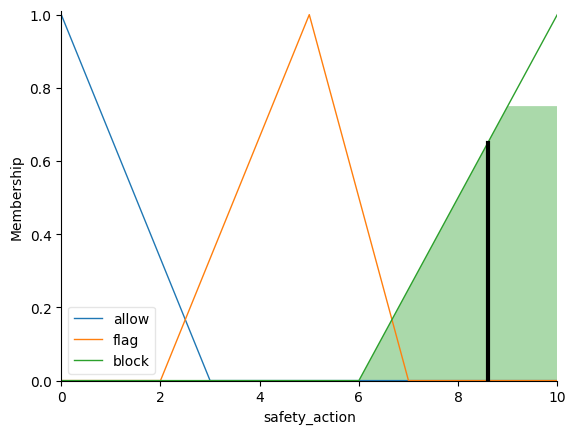

In [14]:
safety_action.view(sim=moderation_sim)
plt.show()

### Summary

Three mechanisms work together across the two notebooks:

* **Z3** formally proves that the functional goal and ethical constraint cannot both be satisfied when safety is disabled and a harmful prompt is submitted.

* **FOL** proves that the responsibility chain from developer decision to victim harm is logically unbreakable.

* **Fuzzy Logic** shows where stakeholder values conflict and what a responsible upstream moderation layer looks like.

Together they show not just that the problem exists but who is responsible for it, how severe it is across a spectrum of prompts, and what a resolution would look like.